<div align="center">

# 🛡️ Insurance Submission Agent

### AI Assisted Insurance Submission Processing and Validation

**Broker Submission → Structured Data → Validation → Decision → Follow Up → Evaluation**

</div>

---

### 🎯 Objective

Insurance submissions often arrive as messy emails, forms, PDFs, and supporting documents. Important information may be missing, inconsistent, or incomplete.

This project builds a lightweight workflow that converts broker submissions into structured records, validates critical information, identifies missing fields, determines the next action, and generates broker follow ups.

The final stage evaluates the system against known ground truth to measure how reliably submissions are processed.

### ⚙️ Workflow

**📨 Broker Submission → 🔍 Information Extraction → ✅ Validation → ⚠️ Missing Information → 📋 Submission Status → 🧭 Next Action → ✉️ Broker Follow Up → 📊 Evaluation**

---

In [5]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt

from datetime import datetime
from pprint import pprint

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Insurance Submission Agent ready.")

Insurance Submission Agent ready.


In [6]:
submissions = [
    {
        "submission_id": "SUB001",
        "email": """
        Hi,

        Please quote ABC Roofing LLC for General Liability.
        They operate in California and have annual revenue of $3.2M.
        They have 24 employees and coverage should begin October 1, 2026.
        Loss history is clean for the past 3 years.
        About 20% of their work is performed by subcontractors.

        Thanks,
        Mike
        """
    },
    {
        "submission_id": "SUB002",
        "email": """
        Hi,

        I need a General Liability quote for Summit Contractors Inc.
        They are located in Texas with annual revenue of $5.5M.
        They have 38 employees and would like coverage starting November 15, 2026.

        Thanks,
        Sarah
        """
    },
    {
        "submission_id": "SUB003",
        "email": """
        Hello,

        Can you help us quote GreenLine Landscaping LLC?
        They operate in Arizona and need General Liability coverage.
        Revenue is approximately $1.8M and they have 16 employees.
        No losses have been reported during the past 3 years.

        Best,
        Daniel
        """
    },
    {
        "submission_id": "SUB004",
        "email": """
        Hi,

        Please review Pacific Electrical Services for General Liability.
        The company operates in Oregon and has annual revenue of $4.1M.
        Coverage is needed starting December 1, 2026.
        They use subcontractors for approximately 35% of their work.

        Thanks,
        Emma
        """
    },
    {
        "submission_id": "SUB005",
        "email": """
        Hi,

        Looking for General Liability coverage for Desert Stone Masonry LLC.
        They operate in Nevada.
        Annual revenue is $2.7M and they have 21 employees.
        Coverage should start January 1, 2027.
        They have had one minor claim during the past 3 years.
        Subcontractors perform about 10% of the work.

        Thanks,
        Alex
        """
    }
]

submissions_df = pd.DataFrame(submissions)

print(f"Loaded {len(submissions_df)} broker submissions.")
display(submissions_df)

Loaded 5 broker submissions.


,submission_id,email
0,SUB001,"\n Hi,\n\n Please quote ABC Roofing LLC for General Liability.\n They operate in California and..."
1,SUB002,"\n Hi,\n\n I need a General Liability quote for Summit Contractors Inc.\n They are located in T..."
2,SUB003,"\n Hello,\n\n Can you help us quote GreenLine Landscaping LLC?\n They operate in Arizona and ne..."
3,SUB004,"\n Hi,\n\n Please review Pacific Electrical Services for General Liability.\n The company opera..."
4,SUB005,"\n Hi,\n\n Looking for General Liability coverage for Desert Stone Masonry LLC.\n They operate ..."


In [7]:
ground_truth = [
    {
        "submission_id": "SUB001",
        "company": "ABC Roofing LLC",
        "coverage": "General Liability",
        "state": "California",
        "revenue": 3200000,
        "employees": 24,
        "effective_date": "2026-10-01",
        "loss_history": "Clean",
        "subcontractor_pct": 20
    },
    {
        "submission_id": "SUB002",
        "company": "Summit Contractors Inc.",
        "coverage": "General Liability",
        "state": "Texas",
        "revenue": 5500000,
        "employees": 38,
        "effective_date": "2026-11-15",
        "loss_history": None,
        "subcontractor_pct": None
    },
    {
        "submission_id": "SUB003",
        "company": "GreenLine Landscaping LLC",
        "coverage": "General Liability",
        "state": "Arizona",
        "revenue": 1800000,
        "employees": 16,
        "effective_date": None,
        "loss_history": "Clean",
        "subcontractor_pct": None
    },
    {
        "submission_id": "SUB004",
        "company": "Pacific Electrical Services",
        "coverage": "General Liability",
        "state": "Oregon",
        "revenue": 4100000,
        "employees": None,
        "effective_date": "2026-12-01",
        "loss_history": None,
        "subcontractor_pct": 35
    },
    {
        "submission_id": "SUB005",
        "company": "Desert Stone Masonry LLC",
        "coverage": "General Liability",
        "state": "Nevada",
        "revenue": 2700000,
        "employees": 21,
        "effective_date": "2027-01-01",
        "loss_history": "One minor claim",
        "subcontractor_pct": 10
    }
]

ground_truth_df = pd.DataFrame(ground_truth)

print("Ground truth created.")
display(ground_truth_df)

Ground truth created.


,submission_id,company,coverage,state,revenue,employees,effective_date,loss_history,subcontractor_pct
0,SUB001,ABC Roofing LLC,General Liability,California,3200000,24.0,2026-10-01,Clean,20.0
1,SUB002,Summit Contractors Inc.,General Liability,Texas,5500000,38.0,2026-11-15,None,NaN
2,SUB003,GreenLine Landscaping LLC,General Liability,Arizona,1800000,16.0,None,Clean,NaN
3,SUB004,Pacific Electrical Services,General Liability,Oregon,4100000,NaN,2026-12-01,None,35.0
4,SUB005,Desert Stone Masonry LLC,General Liability,Nevada,2700000,21.0,2027-01-01,One minor claim,10.0


In [8]:
required_fields = {
    "company": "Named insured",
    "coverage": "Coverage type",
    "state": "Operating state",
    "revenue": "Annual revenue",
    "employees": "Employee count",
    "effective_date": "Effective date",
    "loss_history": "Loss history",
    "subcontractor_pct": "Subcontractor percentage"
}

print(f"Required fields: {len(required_fields)}\n")

for field, label in required_fields.items():
    print(f"{field:<20} {label}")

Required fields: 8

company              Named insured
coverage             Coverage type
state                Operating state
revenue              Annual revenue
employees            Employee count
effective_date       Effective date
loss_history         Loss history
subcontractor_pct    Subcontractor percentage


In [23]:
def extract_submission(email):
    text = " ".join(email.split())

    result = {
        "company": None,
        "coverage": None,
        "state": None,
        "revenue": None,
        "employees": None,
        "effective_date": None,
        "loss_history": None,
        "subcontractor_pct": None
    }

    company_patterns = [
        r"quote (.+?) for General Liability",
        r"quote for (.+?)\.",
        r"quote (.+?)\?",
        r"review (.+?) for General Liability",
        r"coverage for (.+?)\."
    ]

    for pattern in company_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            result["company"] = match.group(1).strip()
            break

    if re.search(r"General Liability", text, re.IGNORECASE):
        result["coverage"] = "General Liability"

    states = ["California", "Texas", "Arizona", "Oregon", "Nevada"]

    for state in states:
        if re.search(rf"\b{state}\b", text, re.IGNORECASE):
            result["state"] = state
            break

    revenue_match = re.search(
        r"(?:annual\s+)?revenue\s+(?:is|of)?\s*(?:approximately\s+)?\$?([\d.]+)\s*M",
        text,
        re.IGNORECASE
    )

    if revenue_match:
        result["revenue"] = int(
            round(float(revenue_match.group(1)) * 1_000_000)
        )

    employee_match = re.search(
        r"(?:have|has)\s+(\d+)\s+employees",
        text,
        re.IGNORECASE
    )

    if employee_match:
        result["employees"] = int(employee_match.group(1))

    date_match = re.search(
        r"(?:begin|starting|start)\s+([A-Za-z]+\s+\d{1,2},\s+\d{4})",
        text,
        re.IGNORECASE
    )

    if date_match:
        try:
            date = datetime.strptime(date_match.group(1), "%B %d, %Y")
            result["effective_date"] = date.strftime("%Y-%m-%d")
        except ValueError:
            pass

    if re.search(
        r"clean|no losses|no losses have been reported",
        text,
        re.IGNORECASE
    ):
        result["loss_history"] = "Clean"

    elif re.search(r"one minor claim", text, re.IGNORECASE):
        result["loss_history"] = "One minor claim"

    subcontractor_patterns = [
        r"(\d+)%\s+of.*?(?:subcontractors|subcontracted)",
        r"subcontractors.*?(?:approximately|about)?\s*(\d+)%",
        r"(?:approximately|about)\s+(\d+)%.*?(?:subcontractors|subcontracted)"
    ]

    for pattern in subcontractor_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            result["subcontractor_pct"] = int(match.group(1))
            break

    return result

In [24]:
test_result = extract_submission(submissions[0]["email"])

print("Extracted information for SUB001:\n")
pprint(test_result)

Extracted information for SUB001:

{'company': 'ABC Roofing LLC',
 'coverage': 'General Liability',
 'effective_date': '2026-10-01',
 'employees': 24,
 'loss_history': 'Clean',
 'revenue': 3200000,
 'state': 'California',
 'subcontractor_pct': 20}


In [26]:
extracted_records = []

for submission in submissions:
    record = extract_submission(submission["email"])
    record["submission_id"] = submission["submission_id"]
    extracted_records.append(record)

extracted_df = pd.DataFrame(extracted_records)

column_order = ["submission_id"] + list(required_fields.keys())
extracted_df = extracted_df[column_order]

print("Extracted submission records:")
display(extracted_df)

Extracted submission records:


,submission_id,company,coverage,state,revenue,employees,effective_date,loss_history,subcontractor_pct
0,SUB001,ABC Roofing LLC,General Liability,California,3200000,24.0,2026-10-01,Clean,20.0
1,SUB002,Summit Contractors Inc,General Liability,Texas,5500000,38.0,2026-11-15,None,NaN
2,SUB003,GreenLine Landscaping LLC,General Liability,Arizona,1800000,16.0,None,Clean,NaN
3,SUB004,Pacific Electrical Services,General Liability,Oregon,4100000,NaN,2026-12-01,None,35.0
4,SUB005,Desert Stone Masonry LLC,General Liability,Nevada,2700000,21.0,2027-01-01,One minor claim,10.0


In [27]:
def find_missing_fields(record):
    missing = []

    for field, label in required_fields.items():
        value = record.get(field)

        if value is None or pd.isna(value):
            missing.append(label)

    return missing


missing_results = []

for record in extracted_records:
    missing = find_missing_fields(record)

    missing_results.append({
        "submission_id": record["submission_id"],
        "missing_count": len(missing),
        "missing_information": ", ".join(missing) if missing else "None"
    })

missing_df = pd.DataFrame(missing_results)

print("Missing information review:")
display(missing_df)

Missing information review:


,submission_id,missing_count,missing_information
0,SUB001,0,None
1,SUB002,2,"Loss history, Subcontractor percentage"
2,SUB003,2,"Effective date, Subcontractor percentage"
3,SUB004,2,"Employee count, Loss history"
4,SUB005,0,None


In [28]:
def determine_status(record):
    missing = find_missing_fields(record)

    if missing:
        return {
            "status": "NEEDS_INFORMATION",
            "next_action": "Request missing information from broker"
        }

    return {
        "status": "READY_FOR_MARKET",
        "next_action": "Continue to carrier review"
    }


workflow_results = []

for record in extracted_records:
    decision = determine_status(record)

    workflow_results.append({
        "submission_id": record["submission_id"],
        "status": decision["status"],
        "next_action": decision["next_action"]
    })

workflow_df = pd.DataFrame(workflow_results)

print("Submission workflow decisions:")
display(workflow_df)

Submission workflow decisions:


,submission_id,status,next_action
0,SUB001,READY_FOR_MARKET,Continue to carrier review
1,SUB002,NEEDS_INFORMATION,Request missing information from broker
2,SUB003,NEEDS_INFORMATION,Request missing information from broker
3,SUB004,NEEDS_INFORMATION,Request missing information from broker
4,SUB005,READY_FOR_MARKET,Continue to carrier review


In [29]:
def generate_broker_followup(record):
    missing = find_missing_fields(record)

    if not missing:
        return "No follow up required. Submission is ready for carrier review."

    company = record.get("company") or "the insured"

    missing_list = "\n".join(
        f"{i}. {field}" for i, field in enumerate(missing, start=1)
    )

    message = f"""Hi,

Thank you for sending the submission for {company}.

Before we can continue reviewing the account, we still need the following information:

{missing_list}

Once we receive these details, we can continue processing the submission.

Thank you."""

    return message


for record in extracted_records:
    if record["submission_id"] == "SUB002":
        print(generate_broker_followup(record))

Hi,

Thank you for sending the submission for Summit Contractors Inc.

Before we can continue reviewing the account, we still need the following information:

1. Loss history
2. Subcontractor percentage

Once we receive these details, we can continue processing the submission.

Thank you.


In [30]:
def validate_submission(record):
    issues = []

    revenue = record.get("revenue")
    employees = record.get("employees")
    subcontractor_pct = record.get("subcontractor_pct")
    effective_date = record.get("effective_date")

    if revenue is not None and revenue <= 0:
        issues.append("Annual revenue must be greater than zero")

    if employees is not None and employees <= 0:
        issues.append("Employee count must be greater than zero")

    if subcontractor_pct is not None:
        if subcontractor_pct < 0 or subcontractor_pct > 100:
            issues.append("Subcontractor percentage must be between 0 and 100")

    if effective_date is not None:
        try:
            datetime.strptime(effective_date, "%Y-%m-%d")
        except ValueError:
            issues.append("Effective date has an invalid format")

    return issues

In [16]:
bad_record = {
    "revenue": -250000,
    "employees": 15,
    "subcontractor_pct": 135,
    "effective_date": "not-a-date"
}

validation_test = validate_submission(bad_record)

print("Validation issues found:\n")

for issue in validation_test:
    print(f"⚠️ {issue}")

Validation issues found:

⚠️ Annual revenue must be greater than zero
⚠️ Subcontractor percentage must be between 0 and 100
⚠️ Effective date has an invalid format


In [31]:
conflict_example = {
    "submission_id": "SUB006",
    "email_revenue": 3200000,
    "application_revenue": 4100000,
    "email_employees": 24,
    "application_employees": 24,
    "email_state": "California",
    "application_state": "California"
}


def detect_conflicts(record):
    conflicts = []

    fields = ["revenue", "employees", "state"]

    for field in fields:
        email_value = record.get(f"email_{field}")
        application_value = record.get(f"application_{field}")

        if (
            email_value is not None
            and application_value is not None
            and email_value != application_value
        ):
            conflicts.append({
                "field": field,
                "email_value": email_value,
                "application_value": application_value
            })

    return conflicts


conflicts = detect_conflicts(conflict_example)

print(f"Submission: {conflict_example['submission_id']}")
print(f"Conflicts detected: {len(conflicts)}\n")

for conflict in conflicts:
    print(f"⚠️ Field: {conflict['field']}")
    print(f"   Broker email: {conflict['email_value']}")
    print(f"   Application:  {conflict['application_value']}")

Submission: SUB006
Conflicts detected: 1

⚠️ Field: revenue
   Broker email: 3200000
   Application:  4100000


In [32]:
def triage_submission(record, conflicts=None):
    missing = find_missing_fields(record)
    validation_issues = validate_submission(record)
    conflicts = conflicts or []

    if validation_issues or conflicts:
        status = "REVIEW_REQUIRED"
        next_action = "Escalate submission for manual review"

    elif missing:
        status = "NEEDS_INFORMATION"
        next_action = "Request missing information from broker"

    else:
        status = "READY_FOR_MARKET"
        next_action = "Continue to carrier review"

    return {
        "status": status,
        "missing_fields": missing,
        "validation_issues": validation_issues,
        "conflicts": conflicts,
        "next_action": next_action
    }

In [33]:
triage_results = []

for record in extracted_records:
    result = triage_submission(record)

    triage_results.append({
        "submission_id": record["submission_id"],
        "status": result["status"],
        "missing_count": len(result["missing_fields"]),
        "validation_issue_count": len(result["validation_issues"]),
        "conflict_count": len(result["conflicts"]),
        "next_action": result["next_action"]
    })

triage_df = pd.DataFrame(triage_results)

print("Submission triage results:")
display(triage_df)

Submission triage results:


,submission_id,status,missing_count,validation_issue_count,conflict_count,next_action
0,SUB001,READY_FOR_MARKET,0,0,0,Continue to carrier review
1,SUB002,NEEDS_INFORMATION,2,0,0,Request missing information from broker
2,SUB003,NEEDS_INFORMATION,2,0,0,Request missing information from broker
3,SUB004,NEEDS_INFORMATION,2,0,0,Request missing information from broker
4,SUB005,READY_FOR_MARKET,0,0,0,Continue to carrier review


In [34]:
conflict_record = extracted_records[0].copy()

conflict_triage = triage_submission(
    conflict_record,
    conflicts=conflicts
)

print("\nConflict example:")
print("Status:", conflict_triage["status"])
print("Next action:", conflict_triage["next_action"])


Conflict example:
Status: REVIEW_REQUIRED
Next action: Escalate submission for manual review


In [35]:
 evaluation_rows = []

for _, truth in ground_truth_df.iterrows():
    submission_id = truth["submission_id"]

    extracted = extracted_df[
        extracted_df["submission_id"] == submission_id
    ].iloc[0]

    for field in required_fields.keys():
        expected = truth[field]
        predicted = extracted[field]

        expected_missing = pd.isna(expected)
        predicted_missing = pd.isna(predicted)

        if expected_missing and predicted_missing:
            correct = True
        elif expected_missing != predicted_missing:
            correct = False
        else:
            correct = str(expected).strip().lower() == str(predicted).strip().lower()

        evaluation_rows.append({
            "submission_id": submission_id,
            "field": field,
            "expected": expected,
            "predicted": predicted,
            "correct": correct
        })

evaluation_df = pd.DataFrame(evaluation_rows)

total_predictions = len(evaluation_df)
correct_predictions = evaluation_df["correct"].sum()
accuracy = correct_predictions / total_predictions * 100

print("Extraction Evaluation")
print("=" * 35)
print(f"Fields evaluated: {total_predictions}")
print(f"Correct: {correct_predictions}")
print(f"Incorrect: {total_predictions - correct_predictions}")
print(f"Overall accuracy: {accuracy:.1f}%")

Extraction Evaluation
Fields evaluated: 40
Correct: 39
Incorrect: 1
Overall accuracy: 97.5%


In [37]:
def values_match(expected, predicted):
    if pd.isna(expected) and pd.isna(predicted):
        return True

    if pd.isna(expected) or pd.isna(predicted):
        return False

    if isinstance(expected, (int, float, np.number)):
        try:
            return np.isclose(float(expected), float(predicted))
        except (ValueError, TypeError):
            return False

    expected_text = str(expected).strip().lower().rstrip(".")
    predicted_text = str(predicted).strip().lower().rstrip(".")

    return expected_text == predicted_text


evaluation_rows = []

for _, truth in ground_truth_df.iterrows():
    submission_id = truth["submission_id"]

    extracted = extracted_df[
        extracted_df["submission_id"] == submission_id
    ].iloc[0]

    for field in required_fields.keys():
        expected = truth[field]
        predicted = extracted[field]

        correct = values_match(expected, predicted)

        evaluation_rows.append({
            "submission_id": submission_id,
            "field": field,
            "expected": expected,
            "predicted": predicted,
            "correct": correct
        })


evaluation_df = pd.DataFrame(evaluation_rows)

total_predictions = len(evaluation_df)
correct_predictions = evaluation_df["correct"].sum()
incorrect_predictions = total_predictions - correct_predictions
accuracy = correct_predictions / total_predictions * 100


print("Extraction Evaluation")
print("=" * 35)

print(f"Fields evaluated: {total_predictions}")
print(f"Correct: {correct_predictions}")
print(f"Incorrect: {incorrect_predictions}")
print(f"Overall accuracy: {accuracy:.1f}%")


field_accuracy = (
    evaluation_df
    .groupby("field")["correct"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="accuracy_percent")
)

print("\nAccuracy by field:")
display(field_accuracy)


errors = evaluation_df[
    evaluation_df["correct"] == False
]

print("\nExtraction errors:")

if errors.empty:
    print("No extraction errors found.")
else:
    display(errors)

Extraction Evaluation
Fields evaluated: 40
Correct: 40
Incorrect: 0
Overall accuracy: 100.0%

Accuracy by field:


,field,accuracy_percent
0,company,100.0
1,coverage,100.0
2,effective_date,100.0
3,employees,100.0
4,loss_history,100.0
5,revenue,100.0
6,state,100.0
7,subcontractor_pct,100.0



Extraction errors:
No extraction errors found.


In [38]:
submission_summary = []

for record in extracted_records:
    triage = triage_submission(record)

    submission_summary.append({
        "submission_id": record["submission_id"],
        "company": record["company"],
        "state": record["state"],
        "revenue": record["revenue"],
        "status": triage["status"],
        "missing_fields": ", ".join(triage["missing_fields"])
            if triage["missing_fields"] else "None",
        "next_action": triage["next_action"]
    })

summary_df = pd.DataFrame(submission_summary)

print("Insurance Submission Processing Summary")
print("=" * 45)

display(summary_df)

Insurance Submission Processing Summary


,submission_id,company,state,revenue,status,missing_fields,next_action
0,SUB001,ABC Roofing LLC,California,3200000,READY_FOR_MARKET,None,Continue to carrier review
1,SUB002,Summit Contractors Inc,Texas,5500000,NEEDS_INFORMATION,"Loss history, Subcontractor percentage",Request missing information from broker
2,SUB003,GreenLine Landscaping LLC,Arizona,1800000,NEEDS_INFORMATION,"Effective date, Subcontractor percentage",Request missing information from broker
3,SUB004,Pacific Electrical Services,Oregon,4100000,NEEDS_INFORMATION,"Employee count, Loss history",Request missing information from broker
4,SUB005,Desert Stone Masonry LLC,Nevada,2700000,READY_FOR_MARKET,None,Continue to carrier review


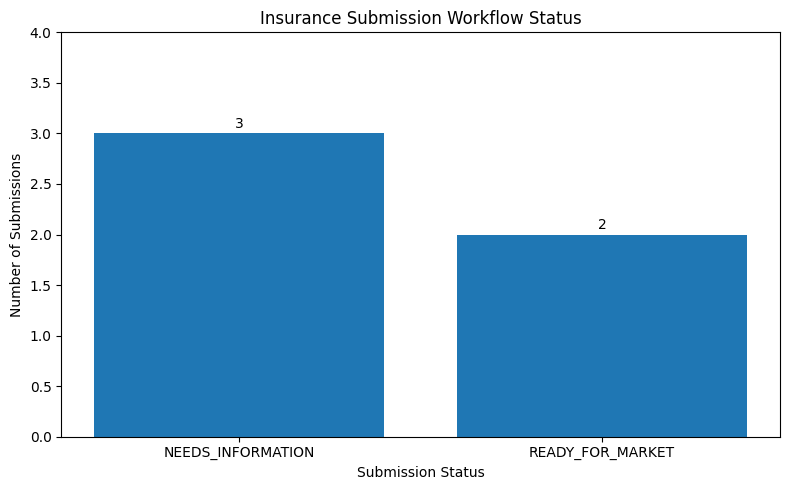

In [39]:
status_counts = summary_df["status"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Insurance Submission Workflow Status")
plt.xlabel("Submission Status")
plt.ylabel("Number of Submissions")

plt.ylim(0, max(status_counts.values) + 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        str(int(height)),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [40]:
challenge_submissions = [
    {
        "submission_id": "TEST001",
        "email": """
        Hello,

        We are looking to place General Liability coverage for
        Horizon Roofing Group. The insured operates in California.
        Annual revenue is $6.4M with 42 employees.
        Requested effective date is October 20, 2026.
        No losses have been reported in the last three years.
        Around 15% of operations are subcontracted.

        Thanks,
        Jordan
        """
    },
    {
        "submission_id": "TEST002",
        "email": """
        Please provide a General Liability quote for BlueRock Builders LLC.
        The company operates in Texas and generates approximately $3.6M
        in annual revenue. They currently have 27 employees.
        Coverage should begin November 5, 2026.
        Subcontractors account for about 25% of their work.

        Thank you.
        """
    },
    {
        "submission_id": "TEST003",
        "email": """
        Can you review Canyon Electrical Inc for General Liability?
        They are based in Arizona with revenue of $2.2M.
        The company has 18 employees and has had no losses
        during the past three years.

        Thanks.
        """
    },
    {
        "submission_id": "TEST004",
        "email": """
        General Liability submission for Northwest Mechanical LLC.
        Operations are in Oregon. Annual revenue is $7.1M.
        The requested policy start date is December 15, 2026.
        Loss history is clean. Approximately 30% of work
        is completed by subcontractors.

        Best,
        Chris
        """
    },
    {
        "submission_id": "TEST005",
        "email": """
        Please quote Silver State Concrete for General Liability.
        They operate in Nevada with annual revenue of $4.8M
        and have 31 employees. Coverage starting January 10, 2027.
        One minor claim was reported during the past three years.
        About 12% of the work is performed by subcontractors.

        Thanks.
        """
    }
]


challenge_ground_truth = [
    {
        "submission_id": "TEST001",
        "company": "Horizon Roofing Group",
        "coverage": "General Liability",
        "state": "California",
        "revenue": 6400000,
        "employees": 42,
        "effective_date": "2026-10-20",
        "loss_history": "Clean",
        "subcontractor_pct": 15
    },
    {
        "submission_id": "TEST002",
        "company": "BlueRock Builders LLC",
        "coverage": "General Liability",
        "state": "Texas",
        "revenue": 3600000,
        "employees": 27,
        "effective_date": "2026-11-05",
        "loss_history": None,
        "subcontractor_pct": 25
    },
    {
        "submission_id": "TEST003",
        "company": "Canyon Electrical Inc",
        "coverage": "General Liability",
        "state": "Arizona",
        "revenue": 2200000,
        "employees": 18,
        "effective_date": None,
        "loss_history": "Clean",
        "subcontractor_pct": None
    },
    {
        "submission_id": "TEST004",
        "company": "Northwest Mechanical LLC",
        "coverage": "General Liability",
        "state": "Oregon",
        "revenue": 7100000,
        "employees": None,
        "effective_date": "2026-12-15",
        "loss_history": "Clean",
        "subcontractor_pct": 30
    },
    {
        "submission_id": "TEST005",
        "company": "Silver State Concrete",
        "coverage": "General Liability",
        "state": "Nevada",
        "revenue": 4800000,
        "employees": 31,
        "effective_date": "2027-01-10",
        "loss_history": "One minor claim",
        "subcontractor_pct": 12
    }
]

challenge_truth_df = pd.DataFrame(challenge_ground_truth)

print(f"Created {len(challenge_submissions)} unseen challenge submissions.")
print("These examples were not used in the initial extraction benchmark.")

Created 5 unseen challenge submissions.
These examples were not used in the initial extraction benchmark.


In [41]:
challenge_extracted = []

for submission in challenge_submissions:
    record = extract_submission(submission["email"])
    record["submission_id"] = submission["submission_id"]
    challenge_extracted.append(record)

challenge_extracted_df = pd.DataFrame(challenge_extracted)

challenge_evaluation = []

for _, truth in challenge_truth_df.iterrows():
    submission_id = truth["submission_id"]

    predicted = challenge_extracted_df[
        challenge_extracted_df["submission_id"] == submission_id
    ].iloc[0]

    for field in required_fields.keys():
        expected_value = truth[field]
        predicted_value = predicted[field]

        challenge_evaluation.append({
            "submission_id": submission_id,
            "field": field,
            "expected": expected_value,
            "predicted": predicted_value,
            "correct": values_match(expected_value, predicted_value)
        })

challenge_evaluation_df = pd.DataFrame(challenge_evaluation)

total = len(challenge_evaluation_df)
correct = challenge_evaluation_df["correct"].sum()
incorrect = total - correct
challenge_accuracy = correct / total * 100

print("Unseen Submission Benchmark")
print("=" * 35)
print(f"Fields evaluated: {total}")
print(f"Correct: {correct}")
print(f"Incorrect: {incorrect}")
print(f"Accuracy: {challenge_accuracy:.1f}%")

challenge_field_accuracy = (
    challenge_evaluation_df
    .groupby("field")["correct"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="accuracy_percent")
)

print("\nAccuracy by field:")
display(challenge_field_accuracy)

challenge_errors = challenge_evaluation_df[
    challenge_evaluation_df["correct"] == False
]

print("\nErrors on unseen submissions:")

if challenge_errors.empty:
    print("No extraction errors found.")
else:
    display(challenge_errors)

Unseen Submission Benchmark
Fields evaluated: 40
Correct: 35
Incorrect: 5
Accuracy: 87.5%

Accuracy by field:


,field,accuracy_percent
0,company,80.0
1,coverage,100.0
2,effective_date,60.0
3,employees,80.0
4,loss_history,100.0
5,revenue,80.0
6,state,100.0
7,subcontractor_pct,100.0



Errors on unseen submissions:


,submission_id,field,expected,predicted,correct
4,TEST001,employees,42.0,NaN,False
5,TEST001,effective_date,2026-10-20,None,False
11,TEST002,revenue,3600000,NaN,False
24,TEST004,company,Northwest Mechanical LLC,None,False
29,TEST004,effective_date,2026-12-15,None,False


In [42]:
demo_submission = challenge_submissions[1]

demo_record = extract_submission(demo_submission["email"])
demo_record["submission_id"] = demo_submission["submission_id"]

demo_triage = triage_submission(demo_record)
demo_followup = generate_broker_followup(demo_record)

print("INSURANCE SUBMISSION AGENT")
print("=" * 50)

print("\n1. BROKER SUBMISSION")
print(demo_submission["email"].strip())

print("\n2. STRUCTURED RECORD")
for field in required_fields:
    print(f"{field:<20}: {demo_record.get(field)}")

print("\n3. TRIAGE")
print("Status:", demo_triage["status"])

print("\nMissing information:")
if demo_triage["missing_fields"]:
    for field in demo_triage["missing_fields"]:
        print(f"  • {field}")
else:
    print("  None")

print("\nValidation issues:")
if demo_triage["validation_issues"]:
    for issue in demo_triage["validation_issues"]:
        print(f"  • {issue}")
else:
    print("  None")

print("\n4. NEXT ACTION")
print(demo_triage["next_action"])

print("\n5. BROKER FOLLOW UP")
print(demo_followup)

INSURANCE SUBMISSION AGENT

1. BROKER SUBMISSION
Please provide a General Liability quote for BlueRock Builders LLC.
        The company operates in Texas and generates approximately $3.6M
        in annual revenue. They currently have 27 employees.
        Coverage should begin November 5, 2026.
        Subcontractors account for about 25% of their work.

        Thank you.

2. STRUCTURED RECORD
company             : BlueRock Builders LLC
coverage            : General Liability
state               : Texas
revenue             : None
employees           : 27
effective_date      : 2026-11-05
loss_history        : None
subcontractor_pct   : 25

3. TRIAGE
Status: NEEDS_INFORMATION

Missing information:
  • Annual revenue
  • Loss history

Validation issues:
  None

4. NEXT ACTION
Request missing information from broker

5. BROKER FOLLOW UP
Hi,

Thank you for sending the submission for BlueRock Builders LLC.

Before we can continue reviewing the account, we still need the following informat

Project files created:
1. initial_evaluation_results.csv
2. challenge_evaluation_results.csv
3. submission_summary.csv
4. challenge_extracted_records.csv
5. submission_dashboard.png
6. example_broker_followup.txt

Final benchmark summary:
Initial benchmark: 40 / 40 fields correct
Unseen benchmark: 35 / 40 fields correct
Unseen accuracy: 87.5%


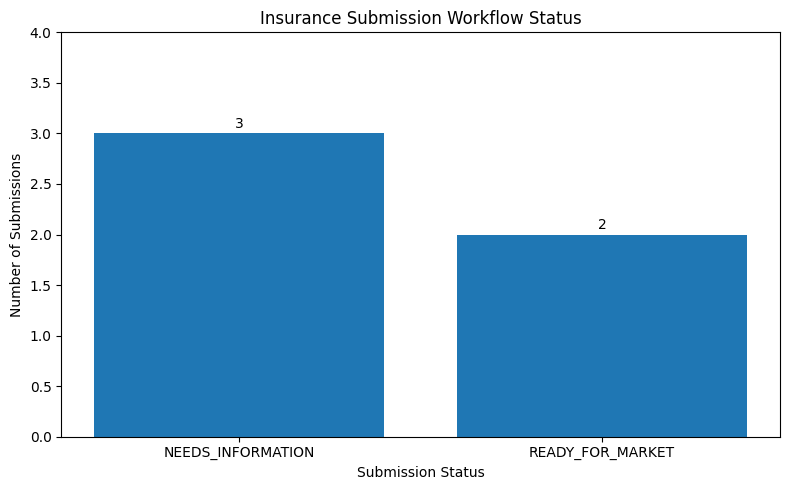

In [43]:
evaluation_df.to_csv(
    "initial_evaluation_results.csv",
    index=False
)

challenge_evaluation_df.to_csv(
    "challenge_evaluation_results.csv",
    index=False
)

summary_df.to_csv(
    "submission_summary.csv",
    index=False
)

challenge_extracted_df.to_csv(
    "challenge_extracted_records.csv",
    index=False
)


status_counts = summary_df["status"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Insurance Submission Workflow Status")
plt.xlabel("Submission Status")
plt.ylabel("Number of Submissions")
plt.ylim(0, max(status_counts.values) + 1)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        str(int(height)),
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "submission_dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

with open("example_broker_followup.txt", "w") as file:
    file.write(demo_followup)


print("Project files created:")
print("1. initial_evaluation_results.csv")
print("2. challenge_evaluation_results.csv")
print("3. submission_summary.csv")
print("4. challenge_extracted_records.csv")
print("5. submission_dashboard.png")
print("6. example_broker_followup.txt")

print("\nFinal benchmark summary:")
print("Initial benchmark: 40 / 40 fields correct")
print(f"Unseen benchmark: {correct} / {total} fields correct")
print(f"Unseen accuracy: {challenge_accuracy:.1f}%")

In [44]:
from google.colab import files

files.download("submission_dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>